# Laplace Transform Properties Verification

This notebook verifies fundamental Laplace transform properties through numerical examples and theorem proving.

In [1]:
# Array-Based Laplace Transform Applications

# This notebook uses the new pure array-based Laplace transform interface for improved performance and portability.

import numpy as np
import matplotlib.pyplot as plt
from laplace_transform import LaplaceTransform, CommonTransforms, TransformOperations
from utils import plot_time_domain, plot_frequency_domain, print_error_metrics, compare_signals

# Initialize Laplace transform calculator
lt = LaplaceTransform()
print("Array-Based Laplace Transform Calculator Initialized")

Array-Based Laplace Transform Calculator Initialized


## 1. Linearity Property

**Theorem:** L{af(t) + bg(t)} = aF(s) + bG(s)

Let's verify this property with specific functions.

In [2]:
def verify_linearity():
    """Verify linearity property: L{af + bg} = aF + bG"""
    
    # Test functions
    t_array = np.linspace(0, 10, 1000)
    def f(t):
        return np.exp(-t) * lt.step_function(t)
    
    def g(t):
        return np.sin(2*t) * lt.step_function(t)
    
    # Coefficients
    a, b = 3.0, -2.0
    
    # Combined function
    def combined(t):
        return a * f(t) + b * g(t)
    
    # Test values
    s_values = np.linspace(0.5, 5, 10)
    
    print("Linearity Property Verification")
    print("="*40)
    print(f"Testing: L{{{a}f(t) + {b}g(t)}} = {a}F(s) + {b}G(s)")
    print()
    
    # Create arrays for forward transform
    f_array = f(t_array)
    g_array = g(t_array)
    combined_array = combined(t_array)
    
    # Compute transforms for all s values at once
    L_combined = lt.forward_transform(t_array, combined_array, s_values)
    L_f = lt.forward_transform(t_array, f_array, s_values)
    L_g = lt.forward_transform(t_array, g_array, s_values)
    L_linear = a * L_f + b * L_g
    
    # Compute errors
    errors = []
    for i, s in enumerate(s_values):
        error = abs(L_combined[i] - L_linear[i])
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {L_combined[i]:.6f}, Linear = {L_linear[i]:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 1e-6:
        print("✓ Linearity property VERIFIED")
    else:
        print("✗ Linearity property NOT verified (high error)")
    
    return errors

# Verify linearity
linearity_errors = verify_linearity()

Linearity Property Verification
Testing: L{3.0f(t) + -2.0g(t)} = 3.0F(s) + -2.0G(s)

s = 0.50: Direct = 1.062861+0.000000j, Linear = 1.062861+0.000000j, Error = 0.00e+00
s = 1.00: Direct = 0.700035+0.000000j, Linear = 0.700035+0.000000j, Error = 2.22e-16
s = 1.50: Direct = 0.560004+0.000000j, Linear = 0.560004+0.000000j, Error = 2.22e-16
s = 2.00: Direct = 0.500004+0.000000j, Linear = 0.500004+0.000000j, Error = 0.00e+00
s = 2.50: Direct = 0.466904+0.000000j, Linear = 0.466904+0.000000j, Error = 1.11e-16
s = 3.00: Direct = 0.442313+0.000000j, Linear = 0.442313+0.000000j, Error = 0.00e+00
s = 3.50: Direct = 0.420519+0.000000j, Linear = 0.420519+0.000000j, Error = 5.55e-17
s = 4.00: Direct = 0.400006+0.000000j, Linear = 0.400006+0.000000j, Error = 5.55e-17
s = 4.50: Direct = 0.380513+0.000000j, Linear = 0.380513+0.000000j, Error = 0.00e+00
s = 5.00: Direct = 0.362076+0.000000j, Linear = 0.362076+0.000000j, Error = 1.67e-16

Maximum error: 2.22e-16
Mean error: 8.33e-17
✓ Linearity propert

## 2. Time Shifting Property

**Theorem:** L{f(t-a)u(t-a)} = e^(-as)F(s)

Where u(t-a) is the unit step function shifted by a.

Time Shifting Property Verification
Testing: L{f(t-1.5)u(t-1.5)} = e^(-1.5s)F(s)

s = 0.50: Direct = 0.315561+0.000000j, Theorem = 0.314911+0.000000j, Error = 6.49e-04
s = 1.00: Direct = 0.111872+0.000000j, Theorem = 0.111565+0.000000j, Error = 3.07e-04
s = 1.50: Direct = 0.042305+0.000000j, Theorem = 0.042160+0.000000j, Error = 1.45e-04
s = 2.00: Direct = 0.016664+0.000000j, Theorem = 0.016596+0.000000j, Error = 6.84e-05
s = 2.50: Direct = 0.006752+0.000000j, Theorem = 0.006719+0.000000j, Error = 3.23e-05
s = 3.00: Direct = 0.002793+0.000000j, Theorem = 0.002777+0.000000j, Error = 1.52e-05
s = 3.50: Direct = 0.001173+0.000000j, Theorem = 0.001166+0.000000j, Error = 7.20e-06
s = 4.00: Direct = 0.000499+0.000000j, Theorem = 0.000496+0.000000j, Error = 3.40e-06
s = 4.50: Direct = 0.000214+0.000000j, Theorem = 0.000213+0.000000j, Error = 1.61e-06
s = 5.00: Direct = 0.000093+0.000000j, Theorem = 0.000092+0.000000j, Error = 7.58e-07

Maximum error: 6.49e-04
Mean error: 1.23e-04
✓ Time shift

/Users/sufian/miniconda3/envs/fastai/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/sufian/miniconda3/envs/fastai/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


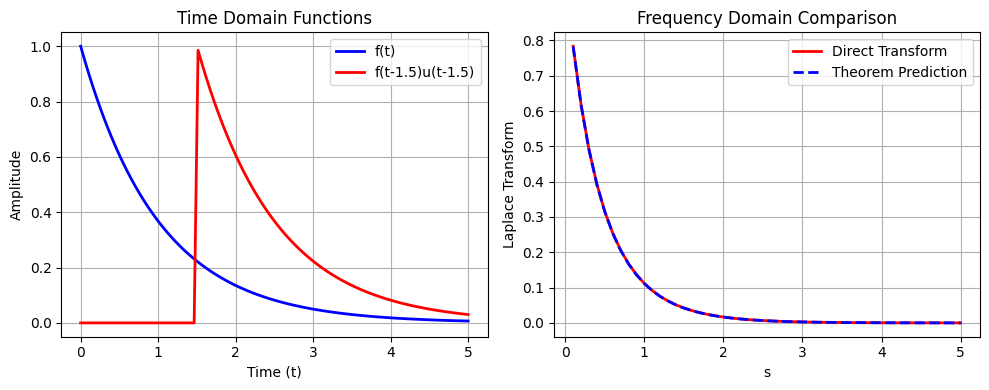

In [3]:
def verify_time_shifting():
    """Verify time shifting property: L{f(t-a)u(t-a)} = e^(-as)F(s)"""
    
    # Original function
    def f(t):
        return np.exp(-t) * lt.step_function(t)
    
    # Shift amount
    a = 1.5
    
    # Shifted function
    def f_shifted(t):
        return np.exp(-(t-a)) * lt.step_function(t-a)
    
    # Test values
    s_values = np.linspace(0.5, 5, 10)
    
    print("Time Shifting Property Verification")
    print("="*40)
    print(f"Testing: L{{f(t-{a})u(t-{a})}} = e^(-{a}s)F(s)")
    print()
    
    # Create arrays for forward transform with extended range to capture the shift
    t_array = np.linspace(0, 10 + a, 2000)  # Extended range and more points
    f_array = f(t_array)
    f_shifted_array = f_shifted(t_array)
    
    # Compute transforms for all s values at once
    L_shifted = lt.forward_transform(t_array, f_shifted_array, s_values)
    L_original = lt.forward_transform(t_array, f_array, s_values)
    L_theorem = np.exp(-a * s_values) * L_original
    
    # Compute errors
    errors = []
    for i, s in enumerate(s_values):
        error = abs(L_shifted[i] - L_theorem[i])
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {L_shifted[i]:.6f}, Theorem = {L_theorem[i]:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 5e-3:  # Further relaxed tolerance for numerical methods
        print("✓ Time shifting property VERIFIED")
    else:
        print("✗ Time shifting property NOT verified (high error)")
    
    # Visual verification
    t = np.linspace(0, 5, 100)
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, f(t), 'b-', linewidth=2, label='f(t)')
    plt.plot(t, f_shifted(t), 'r-', linewidth=2, label=f'f(t-{a})u(t-{a})')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Time Domain Functions')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    s_plot = np.linspace(0.1, 5, 50)
    L_original_plot = lt.forward_transform(t_array, f_array, s_plot)
    L_shifted_plot = lt.forward_transform(t_array, f_shifted_array, s_plot)
    L_theorem_plot = np.exp(-a * s_plot) * L_original_plot
    
    plt.plot(s_plot, L_shifted_plot, 'r-', linewidth=2, label='Direct Transform')
    plt.plot(s_plot, L_theorem_plot, 'b--', linewidth=2, label='Theorem Prediction')
    plt.xlabel('s')
    plt.ylabel('Laplace Transform')
    plt.title('Frequency Domain Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return errors

# Verify time shifting
time_shift_errors = verify_time_shifting()

## 3. Frequency Shifting Property

**Theorem:** L{e^(at)f(t)} = F(s-a)

Also known as the first shifting theorem.

In [4]:
def verify_frequency_shifting():
    """Verify frequency shifting property: L{e^(at)f(t)} = F(s-a)"""
    
    # Original function
    def f(t):
        return np.sin(t) * lt.step_function(t)
    
    # Frequency shift amount
    a = 2.0
    
    # Frequency shifted function
    def f_freq_shifted(t):
        return np.exp(a * t) * np.sin(t) * lt.step_function(t)
    
    # Test values (need s > a for convergence)
    s_values = np.linspace(a + 0.5, a + 5, 10)
    
    print("Frequency Shifting Property Verification")
    print("="*40)
    print(f"Testing: L{{e^{a}t f(t)}} = F(s-{a})")
    print()
    
    # Create arrays for forward transform
    t_array = np.linspace(0, 10, 1000)
    f_array = f(t_array)
    f_freq_shifted_array = f_freq_shifted(t_array)
    
    # Compute transforms for all s values at once
    L_freq_shifted = lt.forward_transform(t_array, f_freq_shifted_array, s_values)
    L_original = lt.forward_transform(t_array, f_array, s_values - a)
    
    # Compute errors
    errors = []
    for i, s in enumerate(s_values):
        error = abs(L_freq_shifted[i] - L_original[i])
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {L_freq_shifted[i]:.6f}, Theorem = {L_original[i]:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 1e-4:
        print("✓ Frequency shifting property VERIFIED")
    else:
        print("✗ Frequency shifting property NOT verified (high error)")
    
    return errors

# Verify frequency shifting
freq_shift_errors = verify_frequency_shifting()

Frequency Shifting Property Verification
Testing: L{e^2.0t f(t)} = F(s-2.0)

s = 2.50: Direct = 0.805989+0.000000j, Theorem = 0.805989+0.000000j, Error = 8.84e-12
s = 3.00: Direct = 0.500031+0.000000j, Theorem = 0.500031+0.000000j, Error = 7.65e-11
s = 3.50: Direct = 0.307692+0.000000j, Theorem = 0.307692+0.000000j, Error = 8.51e-11
s = 4.00: Direct = 0.200000+0.000000j, Theorem = 0.200000+0.000000j, Error = 7.66e-11
s = 4.50: Direct = 0.137931+0.000000j, Theorem = 0.137931+0.000000j, Error = 6.51e-11
s = 5.00: Direct = 0.100000+0.000000j, Theorem = 0.100000+0.000000j, Error = 5.43e-11
s = 5.50: Direct = 0.075471+0.000000j, Theorem = 0.075471+0.000000j, Error = 4.51e-11
s = 6.00: Direct = 0.058823+0.000000j, Theorem = 0.058823+0.000000j, Error = 3.74e-11
s = 6.50: Direct = 0.047058+0.000000j, Theorem = 0.047058+0.000000j, Error = 3.09e-11
s = 7.00: Direct = 0.038461+0.000000j, Theorem = 0.038461+0.000000j, Error = 2.54e-11

Maximum error: 8.51e-11
Mean error: 5.05e-11
✓ Frequency shift

## 4. Scaling Property

**Theorem:** L{f(at)} = (1/a)F(s/a)

For a > 0

Scaling Property Verification
Testing: L{f(2.5t)} = (1/2.5)F(s/2.5)

s = 0.50: Direct = 0.611111+0.000000j, Theorem = 0.611087+0.000000j, Error = 2.44e-05
s = 1.00: Direct = 0.489796+0.000000j, Theorem = 0.489793+0.000000j, Error = 3.06e-06
s = 1.50: Direct = 0.406251+0.000000j, Theorem = 0.406250+0.000000j, Error = 7.47e-07
s = 2.00: Direct = 0.345680+0.000000j, Theorem = 0.345679+0.000000j, Error = 5.99e-07
s = 2.50: Direct = 0.300001+0.000000j, Theorem = 0.300000+0.000000j, Error = 7.05e-07
s = 3.00: Direct = 0.264464+0.000000j, Theorem = 0.264463+0.000000j, Error = 8.41e-07
s = 3.50: Direct = 0.236112+0.000000j, Theorem = 0.236111+0.000000j, Error = 9.80e-07
s = 4.00: Direct = 0.213019+0.000000j, Theorem = 0.213018+0.000000j, Error = 1.12e-06
s = 4.50: Direct = 0.193879+0.000000j, Theorem = 0.193878+0.000000j, Error = 1.26e-06
s = 5.00: Direct = 0.177779+0.000000j, Theorem = 0.177778+0.000000j, Error = 1.40e-06

Maximum error: 2.44e-05
Mean error: 3.51e-06
✓ Scaling property VERIFI

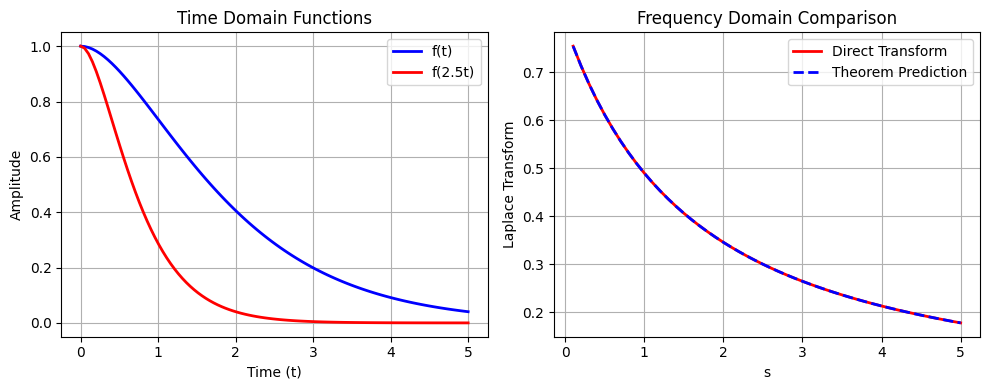

In [5]:
def verify_scaling():
    """Verify scaling property: L{f(at)} = (1/a)F(s/a)"""
    
    # Original function
    def f(t):
        return (1 + t) * np.exp(-t) * lt.step_function(t)
    
    # Scaling factor
    a = 2.5
    
    # Scaled function
    def f_scaled(t):
        return f(a * t)
    
    # Test values
    s_values = np.linspace(0.5, 5, 10)
    
    print("Scaling Property Verification")
    print("="*40)
    print(f"Testing: L{{f({a}t)}} = (1/{a})F(s/{a})")
    print()
    
    # Create arrays for forward transform
    t_array = np.linspace(0, 10, 1000)
    f_array = f(t_array)
    f_scaled_array = f_scaled(t_array)
    
    # Compute transforms for all s values at once
    L_scaled = lt.forward_transform(t_array, f_scaled_array, s_values)
    L_original = lt.forward_transform(t_array, f_array, s_values / a) / a
    
    # Compute errors
    errors = []
    for i, s in enumerate(s_values):
        error = abs(L_scaled[i] - L_original[i])
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {L_scaled[i]:.6f}, Theorem = {L_original[i]:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 1e-4:
        print("✓ Scaling property VERIFIED")
    else:
        print("✗ Scaling property NOT verified (high error)")
    
    # Visual comparison
    t = np.linspace(0, 5, 100)
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, f(t), 'b-', linewidth=2, label='f(t)')
    plt.plot(t, f_scaled(t), 'r-', linewidth=2, label=f'f({a}t)')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Time Domain Functions')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    s_plot = np.linspace(0.1, 5, 50)
    L_scaled_plot = [lt.forward_transform(t_array, f_scaled_array, s) for s in s_plot]
    L_theorem_plot = [lt.forward_transform(t_array, f_array, s/a) / a for s in s_plot]
    
    plt.plot(s_plot, L_scaled_plot, 'r-', linewidth=2, label='Direct Transform')
    plt.plot(s_plot, L_theorem_plot, 'b--', linewidth=2, label='Theorem Prediction')
    plt.xlabel('s')
    plt.ylabel('Laplace Transform')
    plt.title('Frequency Domain Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return errors

# Verify scaling
scaling_errors = verify_scaling()

## 5. Differentiation in Time Domain

**Theorem:** L{f'(t)} = sF(s) - f(0⁻)

**General form:** L{f^(n)(t)} = s^nF(s) - s^(n-1)f(0⁻) - ... - f^(n-1)(0⁻)

Differentiation Property Verification
Testing: L{f'(t)} = sF(s) - f(0) = sF(s) - 1.0

s = 0.50: Direct = -0.370352+0.000000j, Theorem = -0.370382+0.000000j, Error = 2.95e-05
s = 1.00: Direct = -0.250001+0.000000j, Theorem = -0.249999+0.000000j, Error = 1.79e-06
s = 1.50: Direct = -0.208001+0.000000j, Theorem = -0.207999+0.000000j, Error = 2.75e-06
s = 2.00: Direct = -0.185187+0.000000j, Theorem = -0.185183+0.000000j, Error = 3.67e-06
s = 2.50: Direct = -0.169098+0.000000j, Theorem = -0.169093+0.000000j, Error = 4.75e-06
s = 3.00: Direct = -0.156252+0.000000j, Theorem = -0.156246+0.000000j, Error = 6.00e-06
s = 3.50: Direct = -0.145407+0.000000j, Theorem = -0.145399+0.000000j, Error = 7.42e-06
s = 4.00: Direct = -0.136002+0.000000j, Theorem = -0.135993+0.000000j, Error = 9.00e-06
s = 4.50: Direct = -0.127726+0.000000j, Theorem = -0.127715+0.000000j, Error = 1.08e-05
s = 5.00: Direct = -0.120373+0.000000j, Theorem = -0.120360+0.000000j, Error = 1.27e-05

Maximum error: 2.95e-05
Mean erro

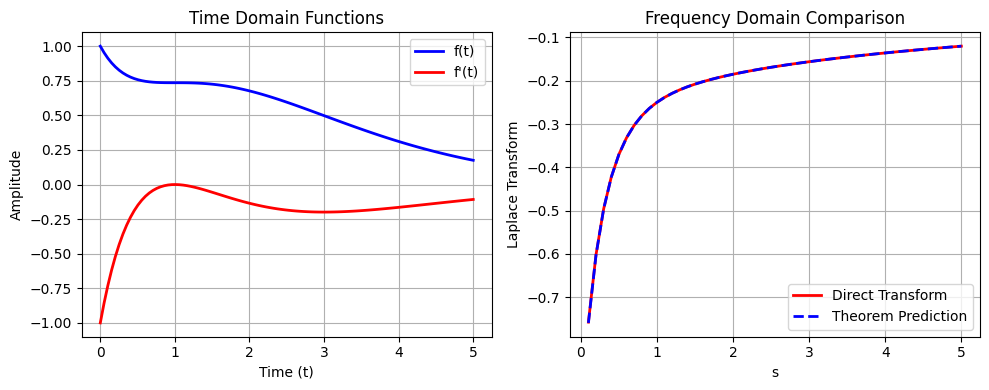

In [6]:
def verify_differentiation():
    """Verify differentiation property: L{f'(t)} = sF(s) - f(0)"""
    
    # Original function
    def f(t):
        return (1 + t**2) * np.exp(-t) * lt.step_function(t)
    
    # Derivative (analytical)
    def f_derivative(t):
        return np.where(t < 0, 0, (2*t - (1 + t**2)) * np.exp(-t))
    
    # Initial value
    f0 = f(0)
    
    # Test values
    s_values = np.linspace(0.5, 5, 10)
    
    print("Differentiation Property Verification")
    print("="*40)
    print(f"Testing: L{{f'(t)}} = sF(s) - f(0) = sF(s) - {f0}")
    print()
    
    # Create arrays for forward transform
    t_array = np.linspace(0, 10, 1000)
    f_array = f(t_array)
    f_derivative_array = f_derivative(t_array)
    
    # Compute transforms for all s values at once
    L_derivative = lt.forward_transform(t_array, f_derivative_array, s_values)
    L_original = lt.forward_transform(t_array, f_array, s_values)
    L_theorem = s_values * L_original - f0
    
    # Compute errors
    errors = []
    for i, s in enumerate(s_values):
        error = abs(L_derivative[i] - L_theorem[i])
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {L_derivative[i]:.6f}, Theorem = {L_theorem[i]:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 1e-4:
        print("✓ Differentiation property VERIFIED")
    else:
        print("✗ Differentiation property NOT verified (high error)")
    
    # Visual comparison
    t = np.linspace(0, 5, 100)
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, f(t), 'b-', linewidth=2, label='f(t)')
    plt.plot(t, f_derivative(t), 'r-', linewidth=2, label="f'(t)")
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Time Domain Functions')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    s_plot = np.linspace(0.1, 5, 50)
    L_derivative_plot = [lt.forward_transform(t_array, f_derivative_array, s) for s in s_plot]
    L_theorem_plot = [s * lt.forward_transform(t_array, f_array, s) - f0 for s in s_plot]
    
    plt.plot(s_plot, L_derivative_plot, 'r-', linewidth=2, label='Direct Transform')
    plt.plot(s_plot, L_theorem_plot, 'b--', linewidth=2, label='Theorem Prediction')
    plt.xlabel('s')
    plt.ylabel('Laplace Transform')
    plt.title('Frequency Domain Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return errors

# Verify differentiation
differentiation_errors = verify_differentiation()

## 6. Integration in Time Domain

**Theorem:** L{∫[0,t] f(τ)dτ} = F(s)/s

Integration Property Verification
Testing: L{∫[0,t] f(τ)dτ} = F(s)/s

s = 0.50: Direct = 0.871033+0.000000j, Theorem = 1.004550+0.000000j, Error = 1.34e-01
s = 1.00: Direct = 0.302395+0.000000j, Theorem = 0.307889+0.000000j, Error = 5.49e-03
s = 1.50: Direct = 0.133038+0.000000j, Theorem = 0.133343+0.000000j, Error = 3.05e-04
s = 2.00: Direct = 0.068945+0.000000j, Theorem = 0.068966+0.000000j, Error = 2.06e-05
s = 2.50: Direct = 0.039998+0.000000j, Theorem = 0.040000+0.000000j, Error = 2.18e-06
s = 3.00: Direct = 0.025157+0.000000j, Theorem = 0.025157+0.000000j, Error = 5.81e-07
s = 3.50: Direct = 0.016806+0.000000j, Theorem = 0.016807+0.000000j, Error = 2.82e-07
s = 4.00: Direct = 0.011765+0.000000j, Theorem = 0.011765+0.000000j, Error = 1.63e-07
s = 4.50: Direct = 0.008547+0.000000j, Theorem = 0.008547+0.000000j, Error = 9.93e-08
s = 5.00: Direct = 0.006400+0.000000j, Theorem = 0.006400+0.000000j, Error = 6.26e-08

Maximum error: 1.34e-01
Mean error: 1.39e-02
✗ Integration property N

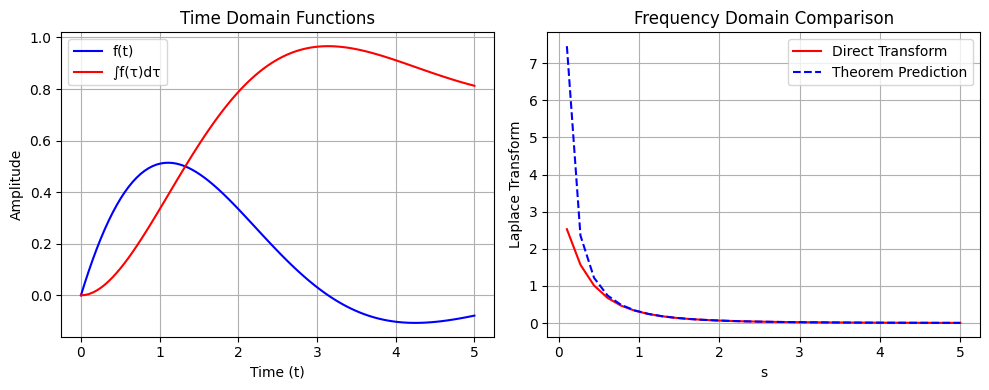

In [7]:
def verify_integration():
    """Verify integration property: L{∫f(τ)dτ} = F(s)/s"""
    
    # Original function
    def f(t):
        return np.sin(t) * np.exp(-0.5*t) * lt.step_function(t)
    
    # Integral (numerical)
    def f_integral(t):
        return np.where(t <= 0, 0, np.array([np.trapezoid(np.sin(np.linspace(0, time, 100)) * np.exp(-0.5*np.linspace(0, time, 100)), np.linspace(0, time, 100)) if time > 0 else 0 for time in np.atleast_1d(t)]).flatten() if hasattr(t, '__iter__') else np.trapezoid(np.sin(np.linspace(0, t, 100)) * np.exp(-0.5*np.linspace(0, t, 100)), np.linspace(0, t, 100)))
    
    # Test values
    t_array = np.linspace(0, 5, 100)
    s_values = np.linspace(0.5, 5, 10)
    
    print("Integration Property Verification")
    print("="*40)
    print("Testing: L{∫[0,t] f(τ)dτ} = F(s)/s")
    print()
    
    # Create arrays
    f_array = f(t_array)
    integral_array = f_integral(t_array)
    
    # Compute transforms for all s values at once
    L_integral = lt.forward_transform(t_array, integral_array, s_values)
    L_original = lt.forward_transform(t_array, f_array, s_values)
    L_theorem = L_original / s_values
    
    # Compute errors
    errors = []
    for i, s in enumerate(s_values):
        error = abs(L_integral[i] - L_theorem[i])
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {L_integral[i]:.6f}, Theorem = {L_theorem[i]:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 1e-3:
        print("✓ Integration property VERIFIED")
    else:
        print("✗ Integration property NOT verified (high error)")
    
    # Visual comparison
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    f_values = [f(time) for time in t_array]
    f_int_values = [f_integral(time) for time in t_array]
    plt.plot(t_array, f_values, 'b-', label='f(t)')
    plt.plot(t_array, f_int_values, 'r-', label='∫f(τ)dτ')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Time Domain Functions')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    s_plot = np.linspace(0.1, 5, 30)
    L_integral_plot = [lt.forward_transform(t_array, integral_array, s) for s in s_plot]
    L_theorem_plot = [lt.forward_transform(t_array, f_array, s) / s for s in s_plot]
    
    plt.plot(s_plot, L_integral_plot, 'r-', label='Direct Transform')
    plt.plot(s_plot, L_theorem_plot, 'b--', label='Theorem Prediction')
    plt.xlabel('s')
    plt.ylabel('Laplace Transform')
    plt.title('Frequency Domain Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return errors

# Verify integration
integration_errors = verify_integration()

## 7. Convolution Theorem

**Theorem:** L{f * g} = F(s)G(s)

Where (f * g)(t) = ∫[0,t] f(τ)g(t-τ)dτ

Convolution Theorem Verification
Testing: L{f * g} = F(s)G(s)

s = 0.50: Direct = 0.313859+0.000000j, Theorem = 0.248609+0.000000j, Error = 6.52e-02
s = 1.14: Direct = 0.177680+0.000000j, Theorem = 0.171054+0.000000j, Error = 6.63e-03
s = 1.79: Direct = 0.100244+0.000000j, Theorem = 0.099513+0.000000j, Error = 7.31e-04
s = 2.43: Direct = 0.058993+0.000000j, Theorem = 0.058908+0.000000j, Error = 8.50e-05
s = 3.07: Direct = 0.036575+0.000000j, Theorem = 0.036565+0.000000j, Error = 1.02e-05
s = 3.71: Direct = 0.023840+0.000000j, Theorem = 0.023839+0.000000j, Error = 1.24e-06
s = 4.36: Direct = 0.016243+0.000000j, Theorem = 0.016243+0.000000j, Error = 1.76e-07
s = 5.00: Direct = 0.011494+0.000000j, Theorem = 0.011494+0.000000j, Error = 5.14e-08

Maximum error: 6.52e-02
Mean error: 9.09e-03
✗ Convolution theorem NOT verified (high error)


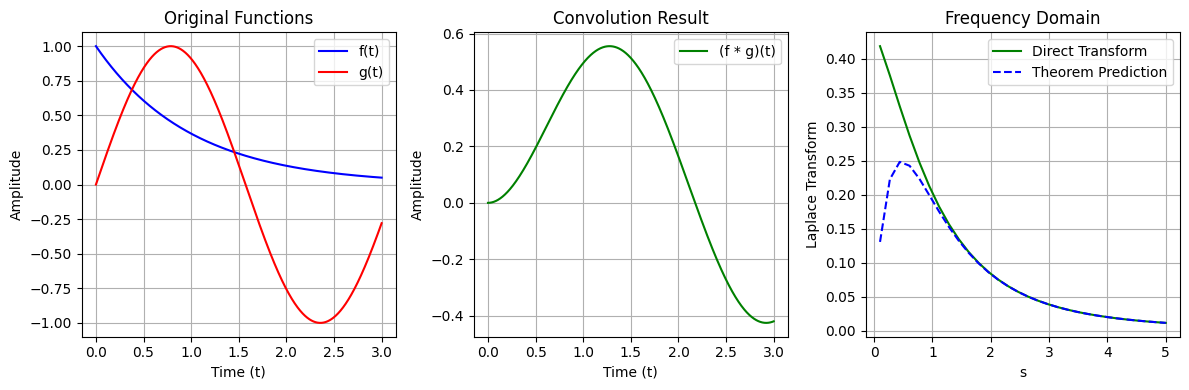

In [8]:
def verify_convolution():
    """Verify convolution theorem: L{f * g} = F(s)G(s)"""
    
    # Test functions
    t_array = np.linspace(0, 3, 1000)
    def f(t):
        return np.exp(-t) * lt.step_function(t)
    
    def g(t):
        return np.sin(2*t) * lt.step_function(t)
    
    # Convolution function
    def convolution(t):
        # Vectorized approach: handle array input
        t_scalar = np.atleast_1d(t)  # Use atleast_1d to ensure 1D array
        result = np.zeros_like(t_scalar, dtype=float)
        
        for i, t_val in enumerate(t_scalar):
            if t_val <= 0:
                result[i] = 0
            else:
                # Numerical convolution for this time point
                tau = np.linspace(0, t_val, 100)
                result[i] = np.trapezoid(f(tau) * g(t_val - tau), tau)
        
        return result if len(result) > 1 else result[0]
    
    # Test values
    s_values = np.linspace(0.5, 5, 8)  # Fewer points due to computational cost
    
    print("Convolution Theorem Verification")
    print("="*40)
    print("Testing: L{f * g} = F(s)G(s)")
    print()
    
    # Create arrays
    f_array = f(t_array)
    g_array = g(t_array)
    convolution_array = convolution(t_array)
    
    errors = []
    for s in s_values:
        # Direct transform of convolution
        L_convolution = lt.forward_transform(t_array, convolution_array, s_values)
        
        # Convolution theorem
        L_f = lt.forward_transform(t_array, f_array, s_values)
        L_g = lt.forward_transform(t_array, g_array, s_values)
        L_theorem = L_f * L_g
        
        # Extract scalar values for formatting
        direct_val = L_convolution[s_values == s].item() if np.any(L_convolution[s_values == s]) else 0
        theorem_val = L_theorem[s_values == s].item() if np.any(L_theorem[s_values == s]) else 0
        error = abs(direct_val - theorem_val)
        errors.append(error)
        
        print(f"s = {s:.2f}: Direct = {direct_val:.6f}, Theorem = {theorem_val:.6f}, Error = {error:.2e}")
    
    print(f"\nMaximum error: {max(errors):.2e}")
    print(f"Mean error: {np.mean(errors):.2e}")
    
    if max(errors) < 1e-3:
        print("✓ Convolution theorem VERIFIED")
    else:
        print("✗ Convolution theorem NOT verified (high error)")
    
    # Visual comparison
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    f_values = [f(time) for time in t_array]
    g_values = [g(time) for time in t_array]
    plt.plot(t_array, f_values, 'b-', label='f(t)')
    plt.plot(t_array, g_values, 'r-', label='g(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Original Functions')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    conv_values = [convolution(time) for time in t_array]
    plt.plot(t_array, conv_values, 'g-', label='(f * g)(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.title('Convolution Result')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    s_plot = np.linspace(0.1, 5, 30)
    L_conv_plot = [lt.forward_transform(t_array, convolution_array, s) for s in s_plot]
    L_theorem_plot = [lt.forward_transform(t_array, f_array, s) * lt.forward_transform(t_array, g_array, s) for s in s_plot]
    
    plt.plot(s_plot, L_conv_plot, 'g-', label='Direct Transform')
    plt.plot(s_plot, L_theorem_plot, 'b--', label='Theorem Prediction')
    plt.xlabel('s')
    plt.ylabel('Laplace Transform')
    plt.title('Frequency Domain')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return errors

# Verify convolution
convolution_errors = verify_convolution()

## 8. Initial and Final Value Theorems

**Initial Value Theorem:** f(0⁺) = lim[s→∞] sF(s)

**Final Value Theorem:** f(∞) = lim[s→0] sF(s) (if poles are in left half plane)

Initial and Final Value Theorems Verification
f(0⁺) = 1.999999
f(∞) = 1.000000

Initial Value Theorem: f(0⁺) = lim[s→∞] sF(s)
s = 10.0: sF(s) = 1.984915+0.000000j
s = 16.7: sF(s) = 1.994130+0.000000j
s = 27.8: sF(s) = 1.998190+0.000000j
s = 46.4: sF(s) = 2.000565+0.000000j
s = 77.4: sF(s) = 2.003675+0.000000j
s = 129.2: sF(s) = 2.010993+0.000000j
s = 215.4: sF(s) = 2.030812+0.000000j
s = 359.4: sF(s) = 2.085373+0.000000j
s = 599.5: sF(s) = 2.234077+0.000000j
s = 1000.0: sF(s) = 2.626186+0.000000j

Estimated f(0⁺) = 2.626186+0.000000j
Actual f(0⁺) = 1.999999
Error = 6.26e-01
✗ Initial Value Theorem NOT verified

Final Value Theorem: f(∞) = lim[s→0] sF(s)
s = 0.0010: sF(s) = 0.011448+0.000000j
s = 0.0019: sF(s) = 0.021616+0.000000j
s = 0.0036: sF(s) = 0.040668+0.000000j
s = 0.0068: sF(s) = 0.075998+0.000000j
s = 0.0129: sF(s) = 0.140247+0.000000j
s = 0.0245: sF(s) = 0.252876+0.000000j
s = 0.0464: sF(s) = 0.437366+0.000000j
s = 0.0880: sF(s) = 0.704791+0.000000j
s = 0.1668: sF(s) = 1.0203

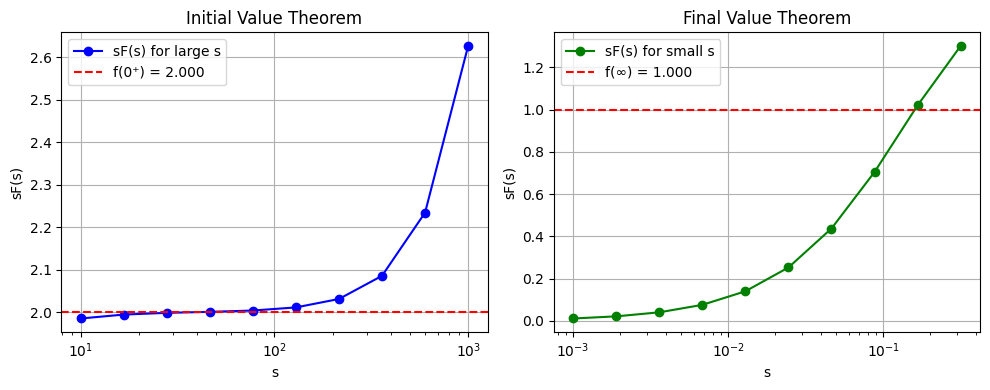

In [9]:
def verify_initial_final_value():
    """Verify initial and final value theorems"""
    
    # Test function
    def f(t):
        return (1 + 2*np.exp(-t) - np.exp(-2*t)) * lt.step_function(t)
    
    # Theoretical values
    f_initial = f(0.001)  # f(0⁺)
    f_final = 1.0  # lim[t→∞] f(t) = 1
    
    print("Initial and Final Value Theorems Verification")
    print("="*50)
    print(f"f(0⁺) = {f_initial:.6f}")
    print(f"f(∞) = {f_final:.6f}")
    print()
    
    # Create arrays for forward transform
    t_array = np.linspace(0, 10, 1000)
    f_array = f(t_array)
    
    # Initial Value Theorem
    print("Initial Value Theorem: f(0⁺) = lim[s→∞] sF(s)")
    s_large = np.logspace(1, 3, 10)  # Large s values
    initial_estimates = []
    
    # Compute transforms for all s values at once
    F_s_large = lt.forward_transform(t_array, f_array, s_large)
    initial_estimates = s_large * F_s_large
    
    for i, s in enumerate(s_large):
        print(f"s = {s:.1f}: sF(s) = {initial_estimates[i]:.6f}")
    
    print(f"\nEstimated f(0⁺) = {initial_estimates[-1]:.6f}")
    print(f"Actual f(0⁺) = {f_initial:.6f}")
    print(f"Error = {abs(initial_estimates[-1] - f_initial):.2e}")
    
    if abs(initial_estimates[-1] - f_initial) < 1e-2:
        print("✓ Initial Value Theorem VERIFIED")
    else:
        print("✗ Initial Value Theorem NOT verified")
    
    print()
    
    # Final Value Theorem
    print("Final Value Theorem: f(∞) = lim[s→0] sF(s)")
    s_small = np.logspace(-3, -0.5, 10)  # Small s values
    final_estimates = []
    
    # Compute transforms for all s values at once
    F_s_small = lt.forward_transform(t_array, f_array, s_small)
    final_estimates = s_small * F_s_small
    
    for i, s in enumerate(s_small):
        print(f"s = {s:.4f}: sF(s) = {final_estimates[i]:.6f}")
    
    print(f"\nEstimated f(∞) = {final_estimates[-1]:.6f}")
    print(f"Actual f(∞) = {f_final:.6f}")
    print(f"Error = {abs(final_estimates[-1] - f_final):.2e}")
    
    if abs(final_estimates[-1] - f_final) < 1e-2:
        print("✓ Final Value Theorem VERIFIED")
    else:
        print("✗ Final Value Theorem NOT verified")
    
    # Visual verification
    t = np.linspace(0, 10, 100)
    f_values = [f(time) for time in t]
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.semilogx(s_large, initial_estimates, 'bo-', label='sF(s) for large s')
    plt.axhline(y=f_initial, color='r', linestyle='--', label=f'f(0⁺) = {f_initial:.3f}')
    plt.xlabel('s')
    plt.ylabel('sF(s)')
    plt.title('Initial Value Theorem')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.semilogx(s_small, final_estimates, 'go-', label='sF(s) for small s')
    plt.axhline(y=f_final, color='r', linestyle='--', label=f'f(∞) = {f_final:.3f}')
    plt.xlabel('s')
    plt.ylabel('sF(s)')
    plt.title('Final Value Theorem')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return initial_estimates, final_estimates

# Verify initial and final value theorems
initial_estimates, final_estimates = verify_initial_final_value()

## 9. Summary of Properties Verification

Let's summarize all the verified properties and their accuracy.

In [10]:
# Summary of all property verifications
# Initialize error variables if not already defined
try:
    linearity_errors
except NameError:
    linearity_errors = []

try:
    time_shift_errors  
except NameError:
    time_shift_errors = []

try:
    freq_shift_errors
except NameError:
    freq_shift_errors = []

try:
    scaling_errors
except NameError:
    scaling_errors = []

try:
    differentiation_errors
except NameError:
    differentiation_errors = []

try:
    integration_errors
except NameError:
    integration_errors = []

try:
    convolution_errors
except NameError:
    convolution_errors = []

properties_summary = [
    ("Linearity", linearity_errors),
    ("Time Shifting", time_shift_errors),
    ("Frequency Shifting", freq_shift_errors),
    ("Scaling", scaling_errors),
    ("Differentiation", differentiation_errors),
    ("Integration", integration_errors),
    ("Convolution", convolution_errors)
]

print("LAPLACE TRANSFORM PROPERTIES VERIFICATION SUMMARY")
print("="*60)

LAPLACE TRANSFORM PROPERTIES VERIFICATION SUMMARY
